# Bias-Variance Tradeoff

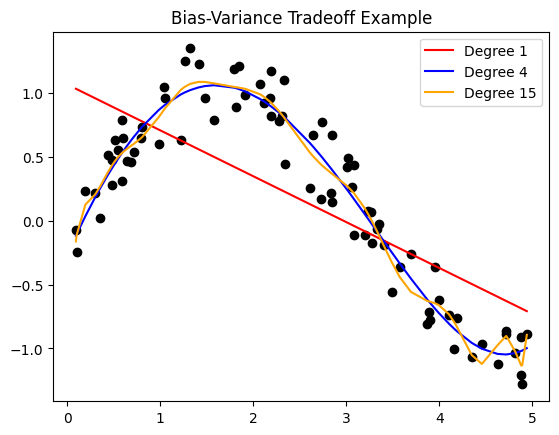

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error


np.random.seed(0)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])


for degree in [1, 4, 15]:  # Bias high (1), balanced (4), variance high (15)
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(X)
    model = LinearRegression().fit(X_poly, y)
    y_pred = model.predict(X_poly)
    plt.plot(X, y_pred, label=f'Degree {degree}',color='blue' if degree == 4 else 'orange' if degree == 15 else 'red')

plt.scatter(X, y, color='black')
plt.legend()
plt.title("Bias-Variance Tradeoff Example")
plt.show()


Degree 1 shows high bias and low variance(underfits the data- too simple to capture underlying pattern)
Degree 4 shows a balanced bias-variance(that is the preferred the model)
Degree 15 shows low bias, high variance 

# parametric vs non-parametric

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3)

# Parametric
lr = LogisticRegression(max_iter=1000).fit(X_train, y_train)

# Non-parametric
knn = KNeighborsClassifier().fit(X_train, y_train)

print("LogReg Acc:", accuracy_score(y_test, lr.predict(X_test)))
print("KNN Acc:", accuracy_score(y_test, knn.predict(X_test)))


LogReg Acc: 0.9111111111111111
KNN Acc: 0.9555555555555556


# Central Limit Theorem

[np.float64(1.863458195563055), np.float64(1.483528485359743), np.float64(2.0756011203104343), np.float64(2.086100855529444), np.float64(1.7434642746720028)]


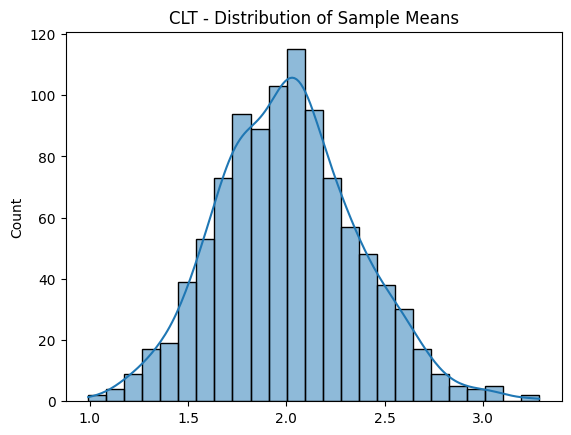

In [5]:
import seaborn as sns

# Create exponential distribution
data = np.random.exponential(scale=2, size=10000)

# Take sample means
sample_means = [np.mean(np.random.choice(data, 30)) for _ in range(1000)]
#ideal population size is atleast 30 samples
print(sample_means[:5])  # Show first 5 sample means
# Show central limit behavior
#kde =True adds a kernel density estimate
#kernel density estimate is a way to estimate the probability density function of a random variable
sns.histplot(sample_means, kde=True)
plt.title("CLT - Distribution of Sample Means")
plt.show()


# Cross-Validation
Practical Idea: Compare CV vs train/test split using cross_val_score

In [10]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
scores = cross_val_score(model, iris.data, iris.target, cv=5)
#If data is imbalanced, stratifiedkfold can be used instead of kfold
#from sklearn.model_selection import StratifiedKFold
#cross_val_score is a function that performs cross-validation on a given model
#cv=5 means 5-fold cross-validation
#cross-validation is a technique to evaluate the performance of a model by splitting the data into training and validation sets multiple times
#It helps to ensure that the model generalizes well to unseen data
#validation set is used to evaluate the performance of the model
#training set is used to train the model
#test set is used to evaluate the performance of the model after training
print("Cross-validation scores:", scores)
print("Average:", scores.mean())


Cross-validation scores: [0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Average: 0.9666666666666668


# P-value
Perform hypothesis test using scipy

In [ ]:
from scipy import stats

# Test: is mean of sample different from population mean 0?
sample = np.random.normal(1, 1, size=30)
t_stat, p_val = stats.ttest_1samp(sample, popmean=0)

print(f"T-stat: {t_stat}, P-value: {p_val}")


T-stat: 6.364985334335947, P-value: 5.8817292462984e-07


### Statistical Test Summary

- **T-statistic:** `6.36`  
  > A higher absolute value indicates a greater difference between the sample mean and the population mean (assumed to be 0 in this case).

- **P-value:** `5.88e-07`  
  > This is a very small number, close to 0.  
  > It represents the probability of observing such a difference (or a more extreme one) if the true mean were 0.

---

### Interpretation

Since the **p-value** is much less than **0.05** (a common significance threshold), we conclude:

The sample mean is **statistically significantly different** from 0.

It is **very unlikely** that your sample comes from a population with a mean of 0.

---

###  Summary

> Your sample mean is **statistically significantly different** from 0.


In [ ]:
%pip install statsmodels

# Multicollinearity
Detect using VIF in a synthetic dataset

In [22]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

np.random.seed(0)
# Create correlated features
X = pd.DataFrame({
    'x1': np.random.rand(100),
    'x2': np.random.rand(100),
})
X['x3'] = X['x1'] * 0.9 + np.random.rand(100) * 0.1

# VIF
X['Intercept'] = 1
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["Feature"] = X.columns
print(vif)
#vif is a measure of how much the variance of an estimated regression coefficient increases when your predictors are correlated
# VIF > 10 indicates high multicollinearity
# VIF < 5 is generally considered acceptable

         VIF    Feature
0  75.504700         x1
1   1.020808         x2
2  75.662956         x3
3  11.867552  Intercept


# KMeans

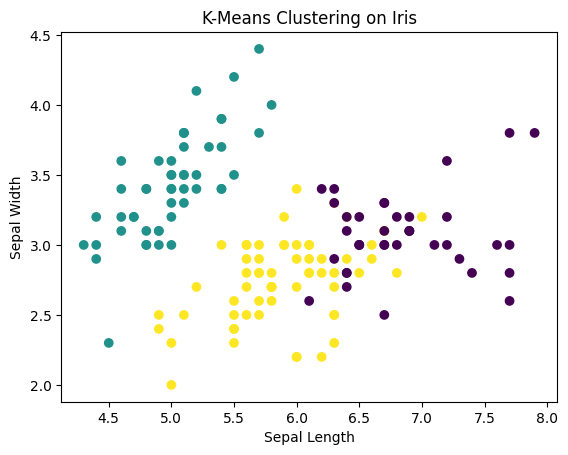

In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(iris.data)

plt.scatter(iris.data[:, 0], iris.data[:, 1], c=labels)
plt.title("K-Means Clustering on Iris")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()


# RandomForest Classifier


In [27]:
import seaborn as sns
df = sns.load_dataset("titanic").dropna(subset=["age", "sex", "survived"])
X = pd.get_dummies(df[["age", "sex"]], drop_first=True)
y = df["survived"]

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier().fit(X, y)
print("Accuracy:", model.score(X, y))


Accuracy: 0.8207282913165266


In [26]:
from sklearn.ensemble import GradientBoostingClassifier

#x_train and y_train is from iris dataset
gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
print("Gradient Boosting Acc:", gb.score(X_test, y_test))


Gradient Boosting Acc: 0.9555555555555556
